In [1]:
import seaborn as sns
import scipy.stats as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, StratifiedKFold, train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/tese André mg feuc/datasets/stress perguntas dataset/Stress Dataset.csv'
df_raw = pd.read_csv(file_path)

# Limpeza
df = df_raw.drop_duplicates().dropna().reset_index(drop=True)
print(f"Shape original: {df_raw.shape} → após limpeza: {df.shape}")

# Grupos de features
physical_features = [
    'Have you noticed a rapid heartbeat or palpitations?',
    'Have you been dealing with anxiety or tension recently?',
    'Have you been dealing with anxiety or tension recently?.1',
    'Have you been getting headaches more often than usual?',
    'Do you face any sleep problems or difficulties falling asleep?',
    'Have you been experiencing any illness or health issues?',
    'Have you gained/lost weight?'
]

subjective_features = [
    'Have you recently experienced stress in your life?',
    'Do you get irritated easily?',
    'Do you have trouble concentrating on your academic tasks?',
    'Have you been feeling sadness or low mood?',
    'Do you often feel lonely or isolated?',
    'Do you feel overwhelmed with your academic workload?',
    'Are you in competition with your peers, and does it affect you?',
    'Do you find that your relationship often causes you stress?',
    'Are you facing any difficulties with your professors or instructors?',
    'Is your working environment unpleasant or stressful?',
    'Do you struggle to find time for relaxation and leisure activities?',
    'Is your hostel or home environment causing you difficulties?',
    'Do you lack confidence in your academic performance?',
    'Do you lack confidence in your choice of academic subjects?',
    'Academic and extracurricular activities conflicting for you?',
    'Do you attend classes regularly?'
]

all_features = physical_features + subjective_features

# Target binário — Distress = 1 (classe positiva)
df['y_binary'] = df['Which type of stress do you primarily experience?'].apply(
    lambda x: 1 if 'Distress' in str(x) and 'Eustress' not in str(x) else 0
)

print(f"\nDistress (1): {df['y_binary'].sum()} ({df['y_binary'].mean()*100:.1f}%)")
print(f"Não-Distress (0): {(df['y_binary']==0).sum()} ({(df['y_binary']==0).mean()*100:.1f}%)")

# MinMaxScaler em todo o dataset antes do split
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(df[all_features]), columns=all_features)
y = df['y_binary']

X_scaled_physical   = X_scaled[physical_features]
X_scaled_subjective = X_scaled[subjective_features]

# Divisão treino/teste
# X_train_all, X_test_all, y_train, y_test = train_test_split(
#     X_scaled, y, test_size=0.2, random_state=42, stratify=y
# )

# X_train_physical   = X_train_all[physical_features]
# X_test_physical    = X_test_all[physical_features]
# X_train_subjective = X_train_all[subjective_features]
# X_test_subjective  = X_test_all[subjective_features]

# print("\nShapes treino/teste:")
# print(f"  All:        {X_train_all.shape} / {X_test_all.shape}")
# print(f"  Physical:   {X_train_physical.shape} / {X_test_physical.shape}")
# print(f"  Subjective: {X_train_subjective.shape} / {X_test_subjective.shape}")

Mounted at /content/drive
Shape original: (843, 26) → após limpeza: (816, 26)

Distress (1): 29 (3.6%)
Não-Distress (0): 787 (96.4%)


Linha de investigação A — Físicas vs Subjectivas vs Todas
5-fold CV | class_weight='balanced' | classe positiva: Distress



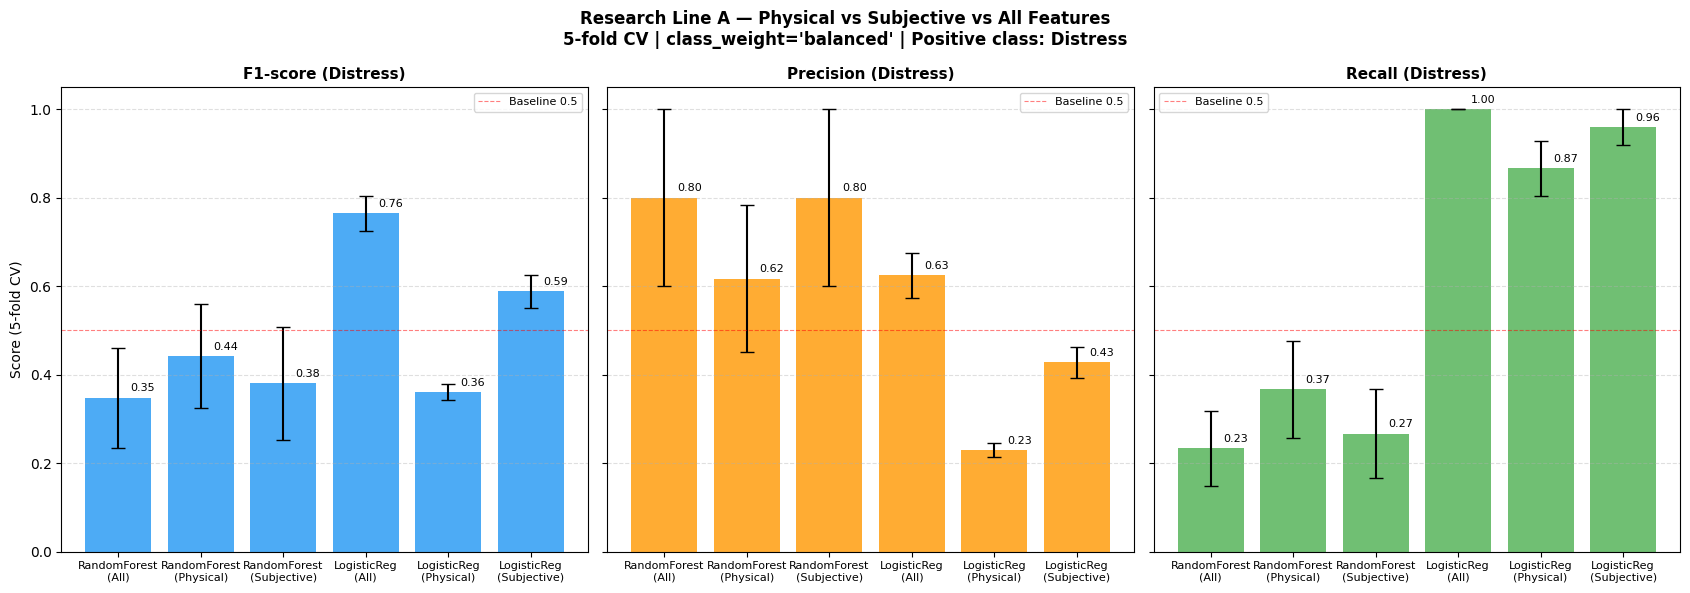


Numerical summary table:


,Modelo,Features,F1 (média),F1 (std),Precision (média),Recall (média),Folds sem previsão Distress
3,LogisticReg,All,0.764,0.079,0.625,1.000,0
5,LogisticReg,Subjective,0.588,0.073,0.428,0.960,0
1,RandomForest,Physical,0.442,0.234,0.617,0.367,1
2,RandomForest,Subjective,0.381,0.256,0.800,0.267,1
4,LogisticReg,Physical,0.360,0.037,0.230,0.867,0
0,RandomForest,All,0.348,0.225,0.800,0.233,1



Melhor modelo: LogisticReg com features 'All'
  F1=0.764 | Precision=0.625 | Recall=1.0

RF Physical (0.442) vs RF Subjective (0.381): Físicas superior
LR All (0.764) vs LR Physical (0.36): queda de 0.404 ao remover subjectivas

Modelos com folds problemáticos: 3


,Modelo,Features,Folds sem previsão Distress
1,RandomForest,Physical,1
2,RandomForest,Subjective,1
0,RandomForest,All,1


CPU times: user 10 s, sys: 44.7 ms, total: 10.1 s
Wall time: 9.84 s


In [2]:
%%time

n_splits = 5
cv_outer = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

scoring = {
    'f1':        make_scorer(f1_score,        zero_division=0),
    'precision': make_scorer(precision_score, zero_division=0),
    'recall':    make_scorer(recall_score,    zero_division=0)
}

experimentos = [
    ('RandomForest', 'All',        RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'), X_scaled,        y),
    ('RandomForest', 'Physical',   RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'), X_scaled_physical,   y),
    ('RandomForest', 'Subjective', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'), X_scaled_subjective, y),
    ('LogisticReg',  'All',        LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),        X_scaled,        y),
    ('LogisticReg',  'Physical',   LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),        X_scaled_physical,   y),
    ('LogisticReg',  'Subjective', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),        X_scaled_subjective, y),
]

resultados = []
for nome, grupo, modelo, X_cv, y_cv in experimentos:
    scores = cross_validate(modelo, X_cv, y_cv, cv=cv_outer,
                            scoring=scoring, return_train_score=False)
    zero_folds = int((scores['test_precision'] == 0).sum())
    resultados.append({
        'Modelo':                      nome,
        'Features':                    grupo,
        'F1 (média)':                  round(scores['test_f1'].mean(), 3),
        'F1 (std)':                    round(scores['test_f1'].std(), 3),
        'Precision (média)':           round(scores['test_precision'].mean(), 3),
        'Recall (média)':              round(scores['test_recall'].mean(), 3),
        'Folds sem previsão Distress': zero_folds
    })

df_resultados = pd.DataFrame(resultados).sort_values('F1 (média)', ascending=False)
print("Linha de investigação A — Físicas vs Subjectivas vs Todas")
print(f"{n_splits}-fold CV | class_weight='balanced' | classe positiva: Distress\n")
# ── GRÁFICO DE BARRAS COM BARRAS DE ERRO (sugestão do orientador) ─────────────

# Guardar os scores brutos de cada fold para as barras de erro
# É necessário re-correr o cross_validate e guardar os arrays completos
scores_por_experimento = {}
for nome, grupo, modelo, X_cv, y_cv in experimentos:
    scores = cross_validate(modelo, X_cv, y_cv, cv=cv_outer,
                            scoring=scoring, return_train_score=False)
    label = f'{nome}\n({grupo})'
    scores_por_experimento[label] = {
        'f1':        scores['test_f1'],
        'precision': scores['test_precision'],
        'recall':    scores['test_recall'],
    }

metricas   = ['f1', 'precision', 'recall']
titulos    = ['F1-score (Distress)', 'Precision (Distress)', 'Recall (Distress)']
labels     = list(scores_por_experimento.keys())
x          = np.arange(len(labels))
width      = 0.25
cores      = ['#2196F3', '#FF9800', '#4CAF50']

fig, axes = plt.subplots(1, 3, figsize=(17, 6), sharey=True)

for ax, metrica, titulo, cor in zip(axes, metricas, titulos, cores):
    medias = [scores_por_experimento[l][metrica].mean()  for l in labels]
    stds   = [st.sem(scores_por_experimento[l][metrica]) for l in labels]

    bars = ax.bar(x, medias, yerr=stds, capsize=5,
                  color=cor, alpha=0.8, error_kw={'linewidth': 1.5})
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_ylabel('Score (5-fold CV)' if ax == axes[0] else '')
    ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, alpha=0.5,
               label='Baseline 0.5')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.legend(fontsize=8)

    # Anotar valores em cima de cada barra
    for bar, media in zip(bars, medias):
        ax.text(bar.get_x() + bar.get_width() / 2 + 0.3,
                bar.get_height() + 0.01,
                f'{media:.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle(
    'Research Line A — Physical vs Subjective vs All Features\n'
    f'{n_splits}-fold CV | class_weight=\'balanced\' | Positive class: Distress',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('barplot_cv_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabela mantém-se para referência numérica
print("\nNumerical summary table:")
display(df_resultados)

# Interpretação automática
melhor = df_resultados.iloc[0]
print(f"\nMelhor modelo: {melhor['Modelo']} com features '{melhor['Features']}'")
print(f"  F1={melhor['F1 (média)']} | Precision={melhor['Precision (média)']} | Recall={melhor['Recall (média)']}")

rf_all  = df_resultados[(df_resultados['Modelo']=='RandomForest') & (df_resultados['Features']=='All')]['F1 (média)'].values[0]
rf_phys = df_resultados[(df_resultados['Modelo']=='RandomForest') & (df_resultados['Features']=='Physical')]['F1 (média)'].values[0]
rf_subj = df_resultados[(df_resultados['Modelo']=='RandomForest') & (df_resultados['Features']=='Subjective')]['F1 (média)'].values[0]
lr_all  = df_resultados[(df_resultados['Modelo']=='LogisticReg')  & (df_resultados['Features']=='All')]['F1 (média)'].values[0]
lr_phys = df_resultados[(df_resultados['Modelo']=='LogisticReg')  & (df_resultados['Features']=='Physical')]['F1 (média)'].values[0]

print(f"\nRF Physical ({rf_phys}) vs RF Subjective ({rf_subj}): "
      f"{'Físicas superior' if rf_phys > rf_subj else 'Subjectivas superior'}")
print(f"LR All ({lr_all}) vs LR Physical ({lr_phys}): "
      f"queda de {round(lr_all - lr_phys, 3)} ao remover subjectivas")

problemas = df_resultados[df_resultados['Folds sem previsão Distress'] > 0]
if len(problemas) > 0:
    print(f"\nModelos com folds problemáticos: {len(problemas)}")
    display(problemas[['Modelo', 'Features', 'Folds sem previsão Distress']])